# Mumbai Traffic Dataset — Exploratory Data Analysis
Raw data sanity check before any preprocessing or model training.

In [2]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# ── PATHS — adjust if your folder structure differs ──────────────────────────
STATIC_PATH     = 'D:/Urban-Traffic-and-Parking-Analysis-using-LSTM-Autoencoders-and-Reinforcement-Learning/backend/data generation/data/static/edges_static.parquet'
TIMESERIES_GLOB = 'D:/Urban-Traffic-and-Parking-Analysis-using-LSTM-Autoencoders-and-Reinforcement-Learning/backend/data generation/data/timeseries/batch_*.parquet'

print('Loading static features …')
df_sta = pd.read_parquet(STATIC_PATH)
print(f'  Static  : {df_sta.shape}')

# Load first 3 batches for fast EDA (representative sample)
batches = sorted(glob.glob(TIMESERIES_GLOB))[:3]
print(f'Loading {len(batches)} timeseries batches (sample) …')
df_ts = pd.concat([pd.read_parquet(b) for b in batches], ignore_index=True)
df_ts['timestamp'] = pd.to_datetime(df_ts['timestamp'])
print(f'  Timeseries sample : {df_ts.shape}')

# Join static for enriched analysis
df = df_ts.merge(df_sta[['edge_id','road_type','road_type_enc','num_lanes',
                          'road_length','corridor_id','zone_id',
                          'lat','lon']], on='edge_id', how='left')
print(f'  Joined shape      : {df.shape}')
print('Done.')

Loading static features …
  Static  : (145265, 17)
Loading 3 timeseries batches (sample) …
  Timeseries sample : (2520000, 25)
  Joined shape      : (2520000, 33)
Done.


## 1. Schema & Basic Info

In [3]:
print('=== STATIC FEATURES ===')
print(df_sta.dtypes.to_string())
print(f'\nShape : {df_sta.shape}')
df_sta.head(3)

=== STATIC FEATURES ===
edge_id                     str
u                         int64
v                         int64
lat                     float32
lon                     float32
road_type                   str
road_type_enc              int8
num_lanes                  int8
oneway                     bool
free_flow_speed         float32
road_length             float32
traffic_signal_count       int8
intersection_count         int8
signals_per_km          float32
susceptibility          float32
zone_id                   int32
corridor_id               int16

Shape : (145265, 17)


,edge_id,u,v,lat,lon,road_type,road_type_enc,num_lanes,oneway,free_flow_speed,road_length,traffic_signal_count,intersection_count,signals_per_km,susceptibility,zone_id,corridor_id
0,245654691_1034965549_0,245654691,1034965549,18.946730,72.832634,secondary,5,2,True,50.0,181.075745,1,1,5.522551,1.1,0,0
1,245654725_245654739_0,245654725,245654739,18.947941,72.795761,residential,2,1,False,30.0,53.579556,0,2,0.000000,0.7,1,0
2,245654725_245654775_0,245654725,245654775,18.947542,72.794823,residential,2,1,False,30.0,428.161469,0,2,0.000000,0.7,1,0


In [4]:
print('=== TIMESERIES FEATURES ===')
print(df_ts.dtypes.to_string())
print(f'\nShape : {df_ts.shape}')
df_ts.head(3)

=== TIMESERIES FEATURES ===
edge_id                              str
timestamp                 datetime64[us]
current_speed                    float32
free_flow_speed                  float32
current_travel_time              float32
free_flow_travel_time            float32
confidence                       float32
road_closure                        int8
incident                            int8
incident_type                       int8
incident_severity                   int8
incidents_nearby                   int16
hourly_rainfall_mm               float32
monsoon_active                      int8
local_train_disruption              int8
is_public_holiday                   int8
school_holiday                      int8
travel_time_ratio                float32
congestion_level                 float32
delay_seconds                    float32
speed_ratio                      float32
time_of_day_sin                  float32
time_of_day_cos                  float32
day_of_week_sin              

,edge_id,timestamp,current_speed,free_flow_speed,current_travel_time,free_flow_travel_time,confidence,road_closure,incident,incident_type,...,is_public_holiday,school_holiday,travel_time_ratio,congestion_level,delay_seconds,speed_ratio,time_of_day_sin,time_of_day_cos,day_of_week_sin,day_of_week_cos
0,245654691_1034965549_0,2024-07-01 00:00:00,45.360001,50.0,14.4,13.0,0.944,0,0,0,...,0,0,1.1022,0.0927,1.3,0.9073,0.00000,1.00000,0.0,1.0
1,245654691_1034965549_0,2024-07-01 01:00:00,46.139999,50.0,14.1,13.0,0.929,0,0,0,...,0,0,1.0837,0.0772,1.1,0.9228,0.25882,0.96593,0.0,1.0
2,245654691_1034965549_0,2024-07-01 02:00:00,46.369999,50.0,14.1,13.0,0.914,0,0,0,...,0,0,1.0783,0.0726,1.0,0.9274,0.50000,0.86603,0.0,1.0


In [5]:
print('=== MISSING VALUES (timeseries) ===')
miss = df_ts.isnull().sum()
print(miss[miss > 0] if miss.any() else 'No missing values — good!')

print('\n=== MISSING VALUES (static) ===')
miss2 = df_sta.isnull().sum()
print(miss2[miss2 > 0] if miss2.any() else 'No missing values — good!')

=== MISSING VALUES (timeseries) ===
No missing values — good!

=== MISSING VALUES (static) ===
No missing values — good!


In [6]:
print('=== TIMESERIES DESCRIBE ===')
cols = ['travel_time_ratio','congestion_level','current_speed',
        'speed_ratio','delay_seconds','confidence',
        'incident','incident_severity','incidents_nearby',
        'hourly_rainfall_mm']
df_ts[cols].describe().round(3)

=== TIMESERIES DESCRIBE ===


,travel_time_ratio,congestion_level,current_speed,speed_ratio,delay_seconds,confidence,incident,incident_severity,incidents_nearby,hourly_rainfall_mm
count,2520000.000,2520000.000,2520000.000,2520000.000,2520000.000,2520000.000,2520000.000,2520000.000,2520000.000,2520000.000
mean,1.698,0.319,24.546,0.682,6.433,0.871,0.044,0.073,52.834,2.887
std,1.057,0.195,10.237,0.194,19.764,0.057,0.204,0.390,36.849,7.217
min,1.000,0.000,0.600,0.050,0.000,0.618,0.000,0.000,0.000,0.000
25%,1.176,0.150,18.400,0.557,0.900,0.834,0.000,0.000,27.000,0.000
50%,1.437,0.304,22.860,0.696,2.500,0.875,0.000,0.000,44.000,0.000
75%,1.795,0.443,27.920,0.850,6.400,0.916,0.000,0.000,70.000,0.000
max,10.000,0.970,117.390,1.000,4877.000,0.990,1.000,4.000,211.000,45.000


## 2. Road Type Distribution

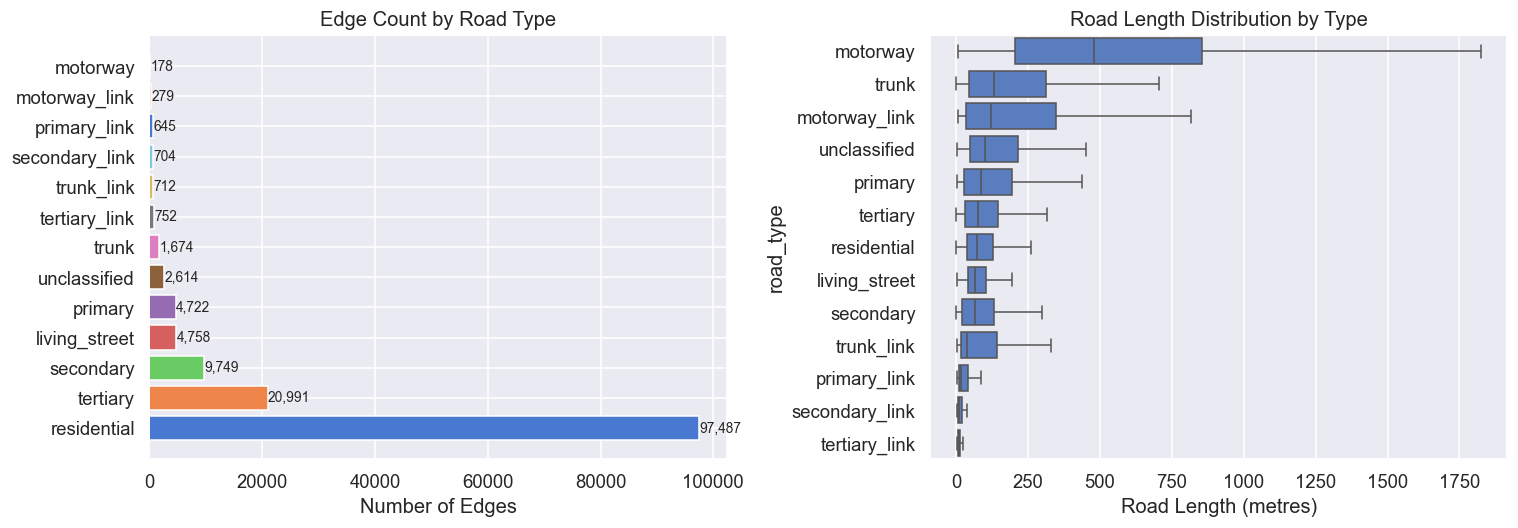

In [9]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Count per road type
# rt_counts = df_sta['road_type'].value_counts()
# axes[0].barh(rt_counts.index, rt_counts.values, color=sns.color_palette('muted', len(rt_counts)))
# axes[0].set_xlabel('Number of Edges')
# axes[0].set_title('Edge Count by Road Type')
# for i, v in enumerate(rt_counts.values):
#     axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# # Road length distribution per type
# order = df_sta.groupby('road_type')['road_length'].median().sort_values(ascending=False).index
# df_sta.boxplot(column='road_length', by='road_type', ax=axes[1],
#                order=order, vert=False, showfliers=False)
# axes[1].set_xlabel('Road Length (metres)')
# axes[1].set_title('Road Length Distribution by Type')
# plt.suptitle('')
# plt.tight_layout()
# plt.show()
# print(rt_counts.to_frame('count'))
# import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
rt_counts = df_sta['road_type'].value_counts()
axes[0].barh(rt_counts.index, rt_counts.values,
             color=sns.color_palette('muted', len(rt_counts)))
axes[0].set_xlabel('Number of Edges')
axes[0].set_title('Edge Count by Road Type')

for i, v in enumerate(rt_counts.values):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# Boxplot (FIXED)
order = df_sta.groupby('road_type')['road_length'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df_sta,
    x='road_length',
    y='road_type',
    order=order,
    ax=axes[1],
    showfliers=False
)

axes[1].set_xlabel('Road Length (metres)')
axes[1].set_title('Road Length Distribution by Type')

plt.tight_layout()
plt.show()

## 3. Temporal Patterns — Are Peaks Realistic?

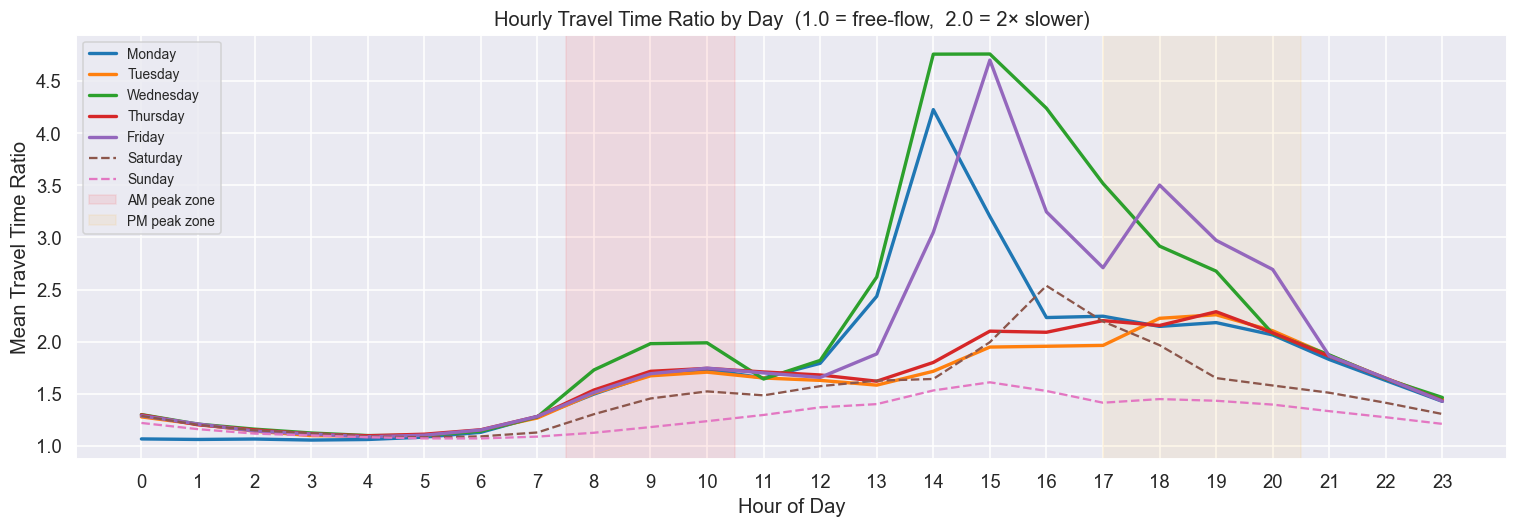

Peak hours summary:
day_name   hour
Friday     8       1.514
           9       1.693
           18      3.502
           19      2.972
Monday     8       1.498
           9       1.682
           18      2.147
           19      2.183
Saturday   8       1.305
           9       1.456
           18      1.967
           19      1.652
Sunday     8       1.127
           9       1.182
           18      1.450
           19      1.434
Thursday   8       1.537
           9       1.716
           18      2.156
           19      2.288
Tuesday    8       1.506
           9       1.673
           18      2.224
           19      2.258
Wednesday  8       1.729
           9       1.982
           18      2.916
           19      2.676


In [8]:
df['hour']      = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek   # 0=Mon … 6=Sun
df['day_name']  = df['timestamp'].dt.day_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Mean travel_time_ratio per hour × day
pivot = df.pivot_table(values='travel_time_ratio', index='hour',
                        columns='day_name', aggfunc='mean')[day_order]

fig, ax = plt.subplots(figsize=(14, 5))
colors = sns.color_palette('tab10', 7)
for i, day in enumerate(day_order):
    ls = '--' if day in ('Saturday','Sunday') else '-'
    lw = 1.5 if day in ('Saturday','Sunday') else 2.2
    ax.plot(pivot.index, pivot[day], label=day, color=colors[i], ls=ls, lw=lw)

ax.axvspan(7.5, 10.5, alpha=0.08, color='red',   label='AM peak zone')
ax.axvspan(17, 20.5,  alpha=0.08, color='orange', label='PM peak zone')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Mean Travel Time Ratio')
ax.set_title('Hourly Travel Time Ratio by Day  (1.0 = free-flow,  2.0 = 2× slower)')
ax.set_xticks(range(0, 24))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print('Peak hours summary:')
print(df[df['hour'].isin([8,9,18,19])]
      .groupby(['day_name','hour'])['travel_time_ratio']
      .mean().round(3).to_string())

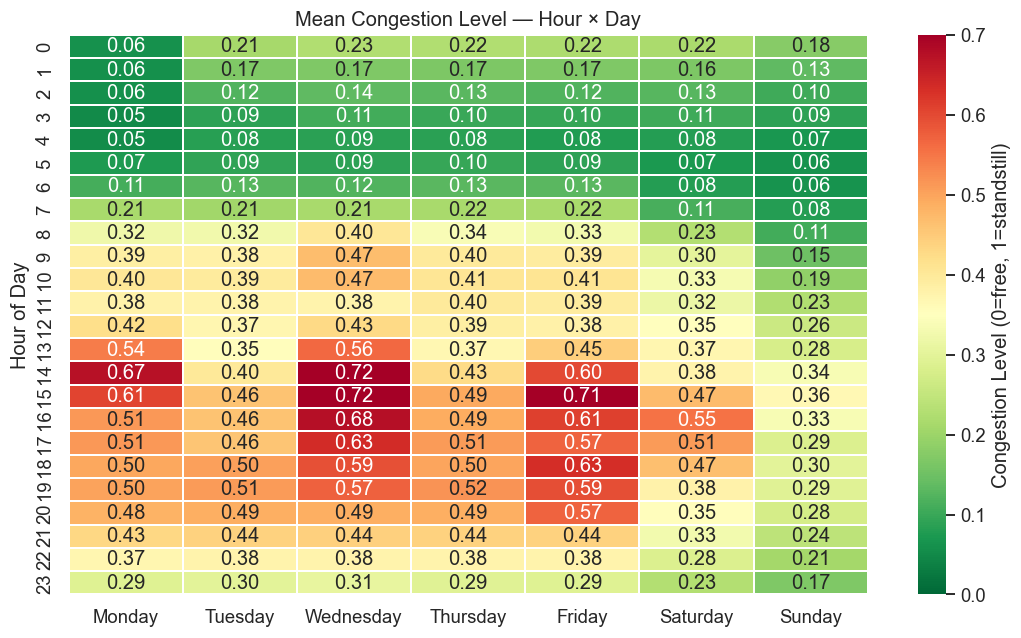

In [10]:
# Congestion heatmap — hour × day
pivot2 = df.pivot_table(values='congestion_level', index='hour',
                         columns='day_name', aggfunc='mean')[day_order]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot2, cmap='RdYlGn_r', annot=True, fmt='.2f',
            linewidths=0.3, ax=ax, vmin=0, vmax=0.7,
            cbar_kws={'label': 'Congestion Level (0=free, 1=standstill)'})
ax.set_title('Mean Congestion Level — Hour × Day')
ax.set_xlabel('')
ax.set_ylabel('Hour of Day')
plt.tight_layout()
plt.show()

## 4. Event Impact — Rain & Train Disruption

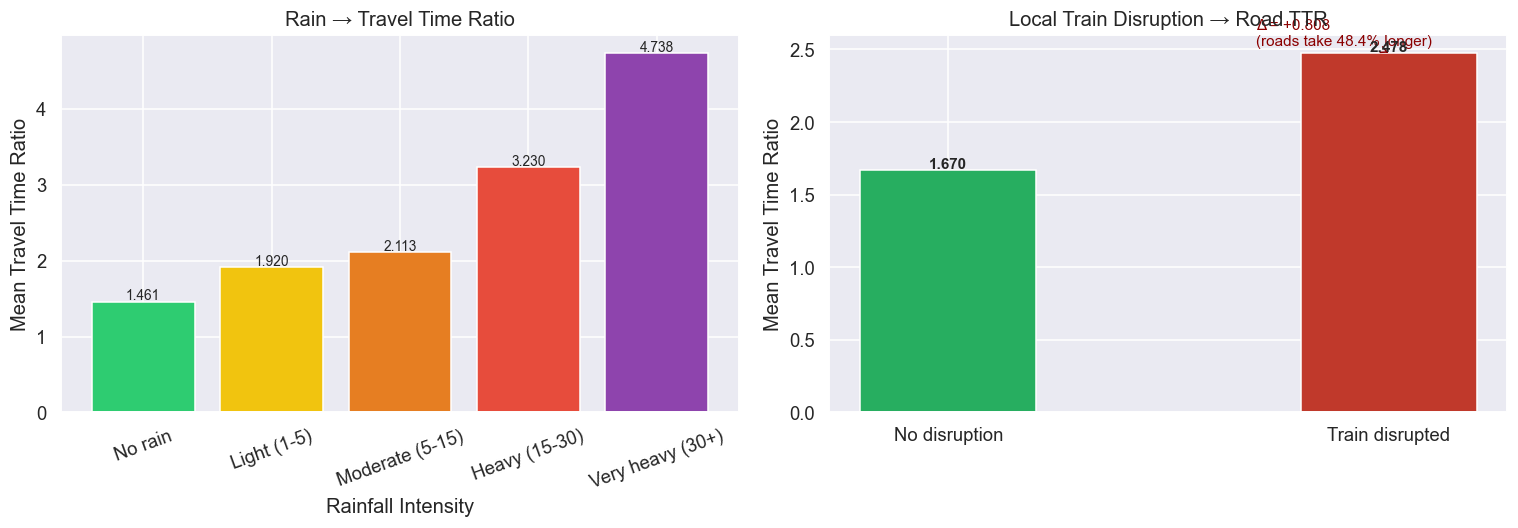

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Rain effect ───────────────────────────────────────────────────────────────
rain_bins = pd.cut(df['hourly_rainfall_mm'],
                   bins=[-0.1, 0.5, 5, 15, 30, 100],
                   labels=['No rain','Light (1-5)','Moderate (5-15)',
                            'Heavy (15-30)','Very heavy (30+)'])
rain_effect = df.groupby(rain_bins, observed=True)['travel_time_ratio'].mean()

bars = axes[0].bar(rain_effect.index, rain_effect.values,
                   color=['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad'])
axes[0].set_xlabel('Rainfall Intensity')
axes[0].set_ylabel('Mean Travel Time Ratio')
axes[0].set_title('Rain → Travel Time Ratio')
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, rain_effect.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.3f}', ha='center', fontsize=9)

# ── Train disruption effect ───────────────────────────────────────────────────
td_effect = df.groupby('local_train_disruption')['travel_time_ratio'].mean()
bars2 = axes[1].bar(['No disruption','Train disrupted'],
                    td_effect.values, color=['#27ae60','#c0392b'], width=0.4)
axes[1].set_ylabel('Mean Travel Time Ratio')
axes[1].set_title('Local Train Disruption → Road TTR')
diff = td_effect[1] - td_effect[0]
axes[1].annotate(f'Δ = +{diff:.3f}\n(roads take {diff/td_effect[0]*100:.1f}% longer)',
                 xy=(1, td_effect[1]), xytext=(0.7, td_effect[1] + 0.05),
                 fontsize=10, color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred'))
for bar, v in zip(bars2, td_effect.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

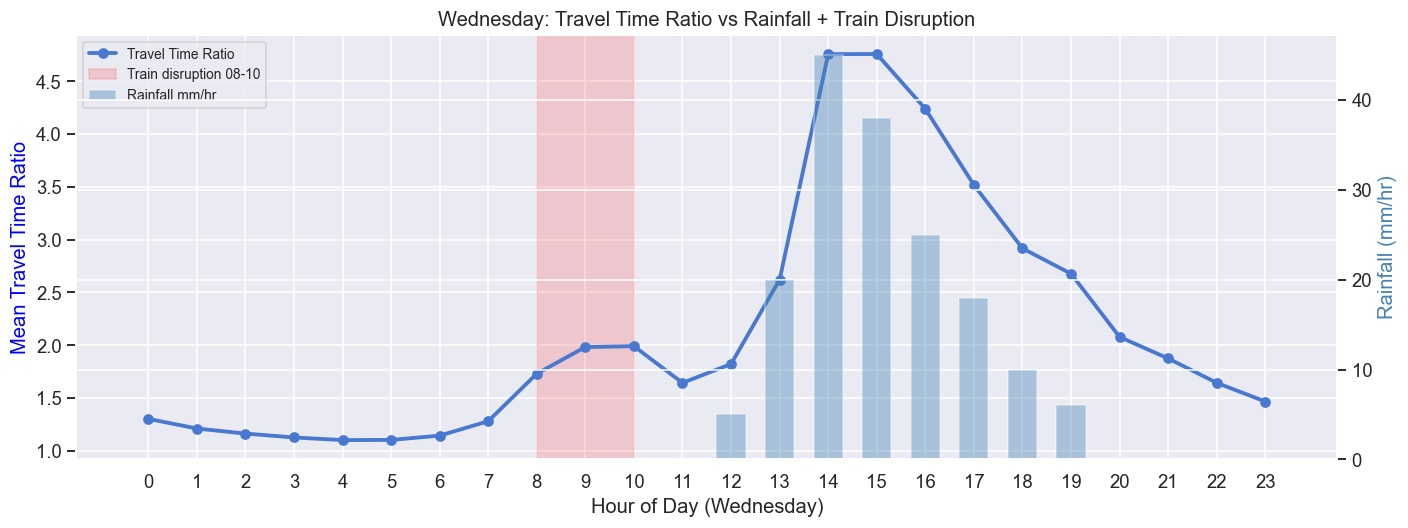

In [12]:
# Timeline showing rain + train disruption overlaid on TTR (Wednesday)
wed = df[df['day_name'] == 'Wednesday'].groupby('hour').agg(
    ttr      = ('travel_time_ratio','mean'),
    rain     = ('hourly_rainfall_mm','mean'),
    train_dis= ('local_train_disruption','mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.plot(wed['hour'], wed['ttr'], 'b-o', lw=2.5, label='Travel Time Ratio')
ax2.bar(wed['hour'], wed['rain'], alpha=0.4, color='steelblue', label='Rainfall mm/hr', width=0.6)

# Train disruption window (Wed 08-10)
ax1.axvspan(8, 10, alpha=0.15, color='red', label='Train disruption 08-10')

ax1.set_xlabel('Hour of Day (Wednesday)')
ax1.set_ylabel('Mean Travel Time Ratio', color='blue')
ax2.set_ylabel('Rainfall (mm/hr)', color='steelblue')
ax1.set_title('Wednesday: Travel Time Ratio vs Rainfall + Train Disruption')
ax1.set_xticks(range(0, 24))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Incident Analysis

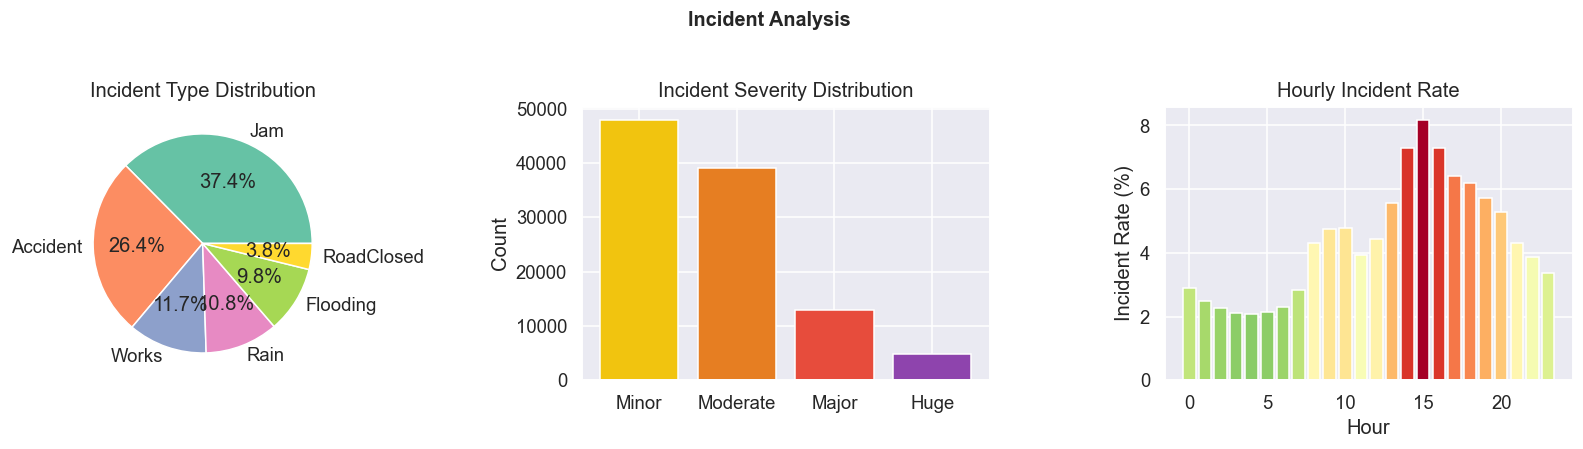

Overall incident rate: 4.37% of edge-hours


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Incident type distribution (only where incident=1)
inc_df = df[df['incident'] == 1]
type_map = {1:'Accident', 4:'Rain', 6:'Jam', 8:'RoadClosed', 9:'Works', 11:'Flooding'}
type_counts = inc_df['incident_type'].map(type_map).value_counts()
axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(type_counts)))
axes[0].set_title('Incident Type Distribution')

# Incident severity distribution
sev_map = {0:'None',1:'Minor',2:'Moderate',3:'Major',4:'Huge'}
sev_counts = inc_df['incident_severity'].map(sev_map).value_counts()
sev_order  = ['Minor','Moderate','Major','Huge']
sev_vals   = [sev_counts.get(s, 0) for s in sev_order]
axes[1].bar(sev_order, sev_vals,
            color=['#f1c40f','#e67e22','#e74c3c','#8e44ad'])
axes[1].set_title('Incident Severity Distribution')
axes[1].set_ylabel('Count')

# Incident rate per hour
hourly_inc = df.groupby('hour')['incident'].mean() * 100
axes[2].bar(hourly_inc.index, hourly_inc.values,
            color=plt.cm.RdYlGn_r(hourly_inc.values / hourly_inc.max()))
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Incident Rate (%)')
axes[2].set_title('Hourly Incident Rate')

plt.suptitle('Incident Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Overall incident rate: {df["incident"].mean()*100:.2f}% of edge-hours')

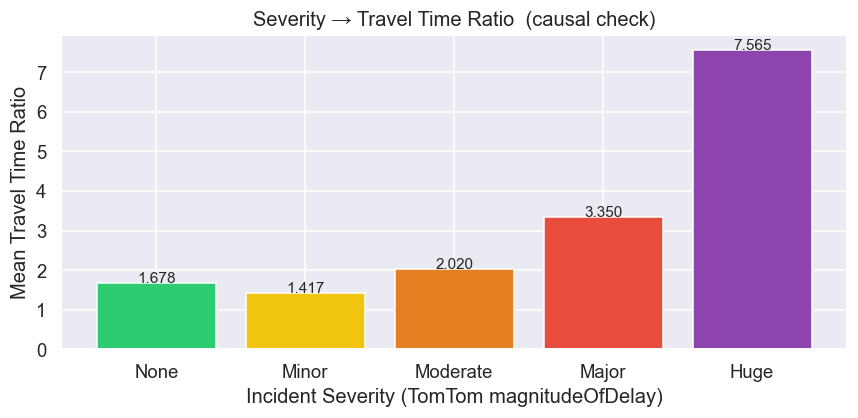

Monotonically increasing? False


In [14]:
# Does incident_severity actually correlate with travel_time_ratio?
fig, ax = plt.subplots(figsize=(8, 4))
sev_ttr = df.groupby('incident_severity')['travel_time_ratio'].mean()
ax.bar([sev_map.get(i, str(i)) for i in sev_ttr.index], sev_ttr.values,
       color=['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad'])
ax.set_xlabel('Incident Severity (TomTom magnitudeOfDelay)')
ax.set_ylabel('Mean Travel Time Ratio')
ax.set_title('Severity → Travel Time Ratio  (causal check)')
for i, v in enumerate(sev_ttr.values):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print('Monotonically increasing?', all(np.diff(sev_ttr.values) > 0))

## 6. Road Type Effect on Congestion

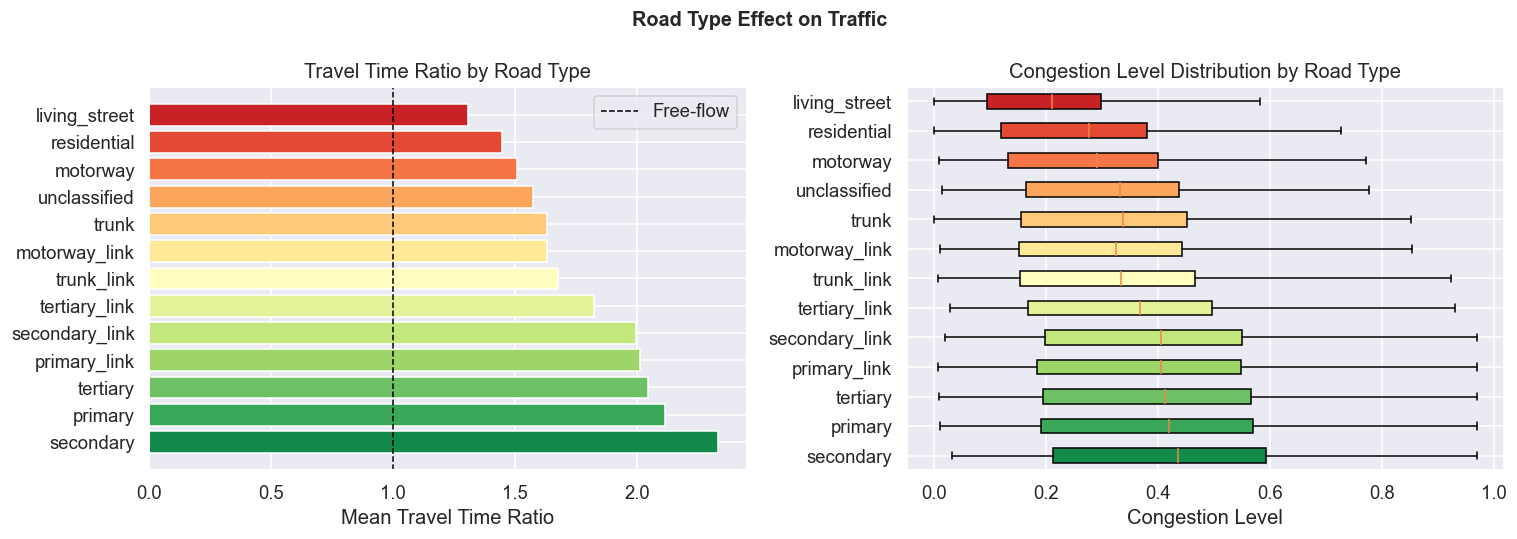

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rt_order = (df.groupby('road_type')['travel_time_ratio']
              .mean().sort_values(ascending=False).index.tolist())

# Mean TTR by road type
rt_ttr = df.groupby('road_type')['travel_time_ratio'].mean().reindex(rt_order)
axes[0].barh(rt_order, rt_ttr.values,
             color=sns.color_palette('RdYlGn_r', len(rt_order)))
axes[0].axvline(1.0, color='black', ls='--', lw=1, label='Free-flow')
axes[0].set_xlabel('Mean Travel Time Ratio')
axes[0].set_title('Travel Time Ratio by Road Type')
axes[0].legend()

# Distribution box
data_by_type = [df[df['road_type'] == rt]['congestion_level'].sample(
                    min(2000, len(df[df['road_type']==rt]))).values
                for rt in rt_order]
bp = axes[1].boxplot(data_by_type, vert=False, labels=rt_order,
                     patch_artist=True, showfliers=False)
colors = sns.color_palette('RdYlGn_r', len(rt_order))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[1].set_xlabel('Congestion Level')
axes[1].set_title('Congestion Level Distribution by Road Type')

plt.suptitle('Road Type Effect on Traffic', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Spatial Distribution — Lat/Lon Congestion Heatmap

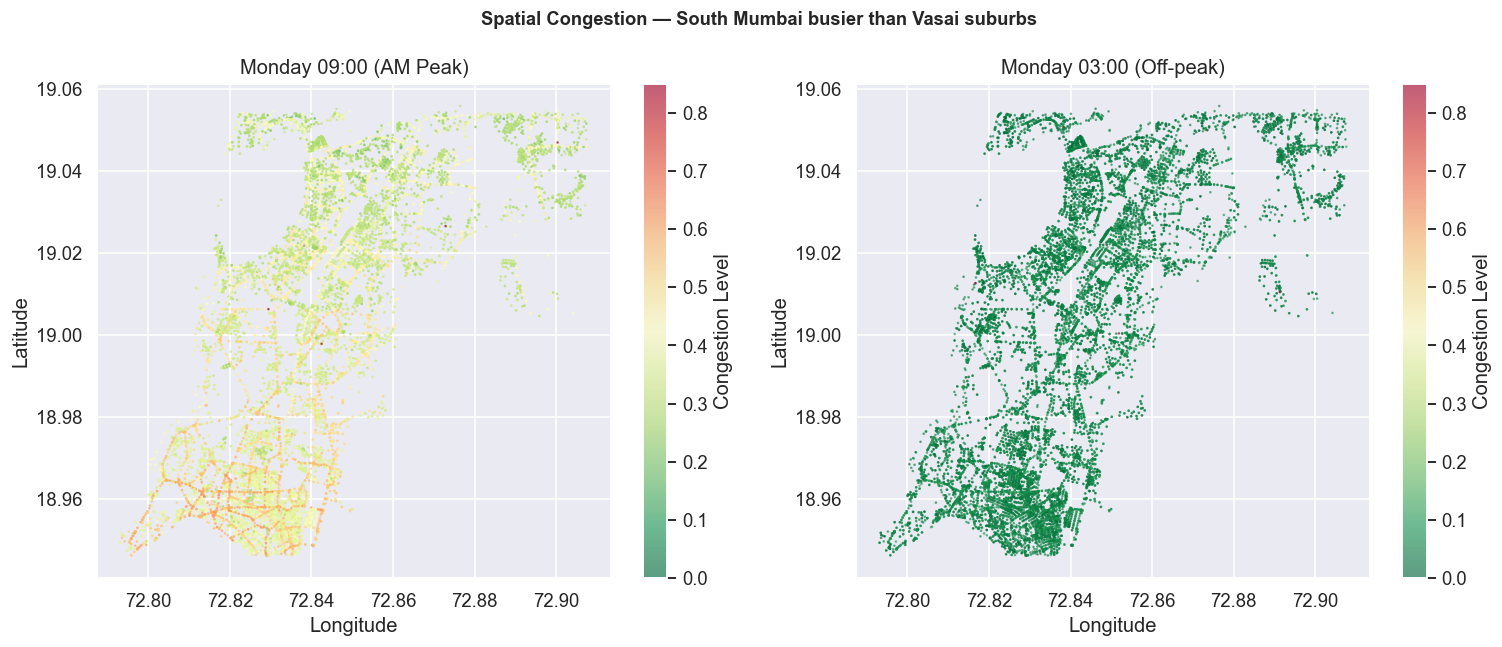

North (Vasai area, lat>19.3) vs South (Churchgate area, lat<19.05) avg congestion:
  North avg : nan
  South avg : 0.390
  Ratio S/N : nanx  (South should be ~1.5-2x busier)


In [16]:
# Sample one specific hour (Monday 9am — peak) for spatial view
peak_hour = df[(df['day_name']=='Monday') & (df['hour']==9)].copy()
off_hour  = df[(df['day_name']=='Monday') & (df['hour']==3)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, d, title in zip(axes,
                         [peak_hour, off_hour],
                         ['Monday 09:00 (AM Peak)', 'Monday 03:00 (Off-peak)']):
    sc = ax.scatter(d['lon'], d['lat'], c=d['congestion_level'],
                    cmap='RdYlGn_r', s=0.5, alpha=0.6, vmin=0, vmax=0.85)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    plt.colorbar(sc, ax=ax, label='Congestion Level')

plt.suptitle('Spatial Congestion — South Mumbai busier than Vasai suburbs',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('North (Vasai area, lat>19.3) vs South (Churchgate area, lat<19.05) avg congestion:')
north = peak_hour[peak_hour['lat'] > 19.30]['congestion_level'].mean()
south = peak_hour[peak_hour['lat'] < 19.05]['congestion_level'].mean()
print(f'  North avg : {north:.3f}')
print(f'  South avg : {south:.3f}')
print(f'  Ratio S/N : {south/north:.2f}x  (South should be ~1.5-2x busier)')

## 8. Correlation Analysis

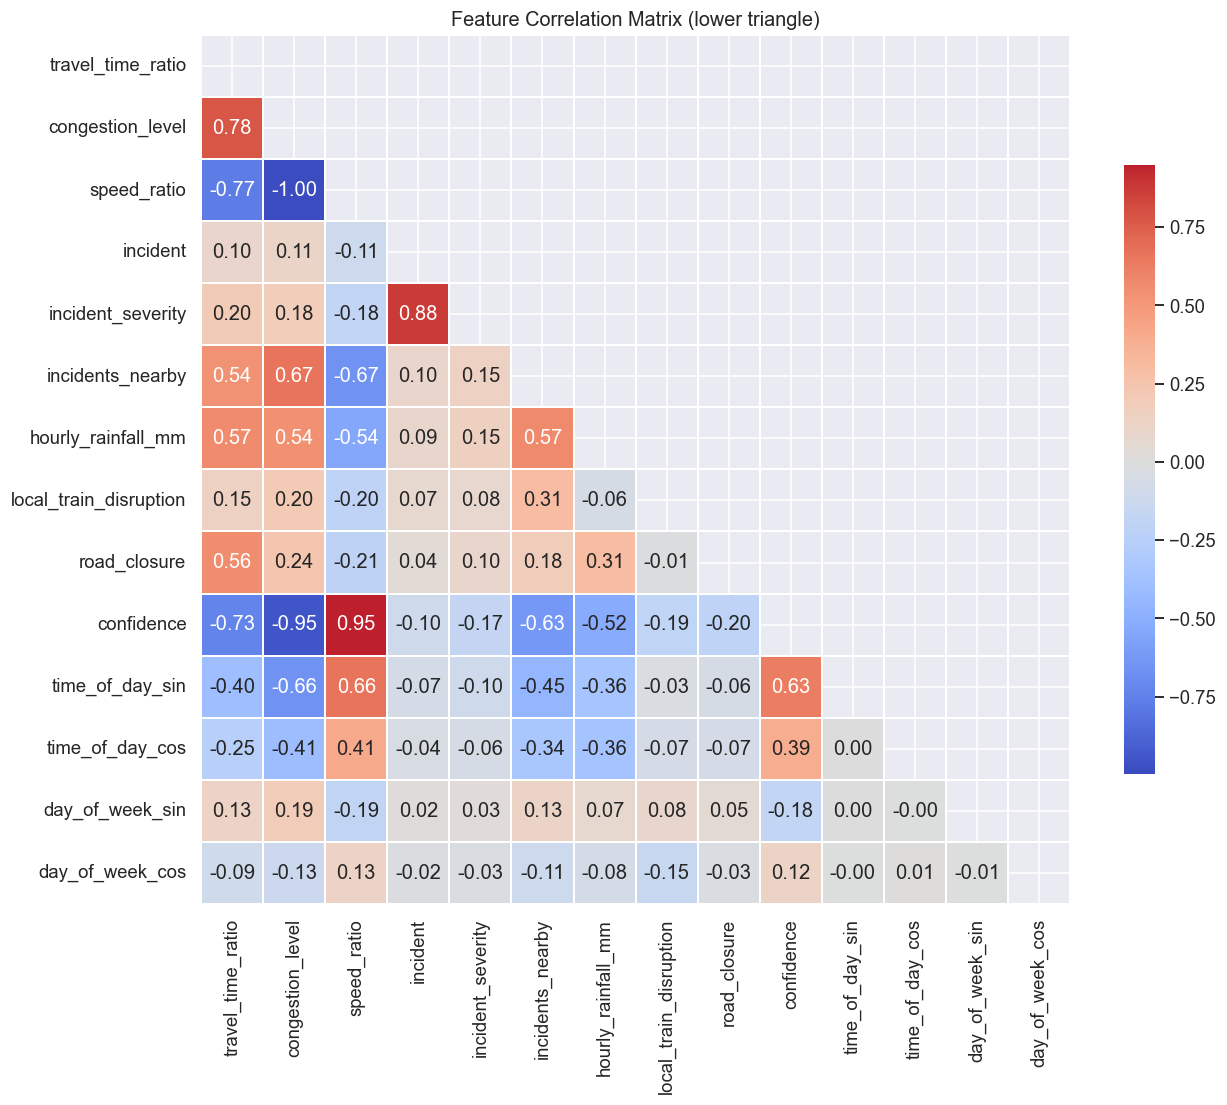


Top correlations with travel_time_ratio:
congestion_level          0.781761
speed_ratio               0.771070
confidence                0.733230
hourly_rainfall_mm        0.567110
road_closure              0.556749
incidents_nearby          0.536177
time_of_day_sin           0.404278
time_of_day_cos           0.245296
incident_severity         0.197053
local_train_disruption    0.146039


In [17]:
corr_cols = [
    'travel_time_ratio', 'congestion_level', 'speed_ratio',
    'incident', 'incident_severity', 'incidents_nearby',
    'hourly_rainfall_mm', 'local_train_disruption',
    'road_closure', 'confidence',
    'time_of_day_sin', 'time_of_day_cos',
    'day_of_week_sin', 'day_of_week_cos',
]
sample = df[corr_cols].sample(min(50_000, len(df)), random_state=42)
corr = sample.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.3, ax=ax,
            square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTop correlations with travel_time_ratio:')
print(corr['travel_time_ratio'].drop('travel_time_ratio').abs()
         .sort_values(ascending=False).head(10).to_string())

## 9. Target Variable Distribution

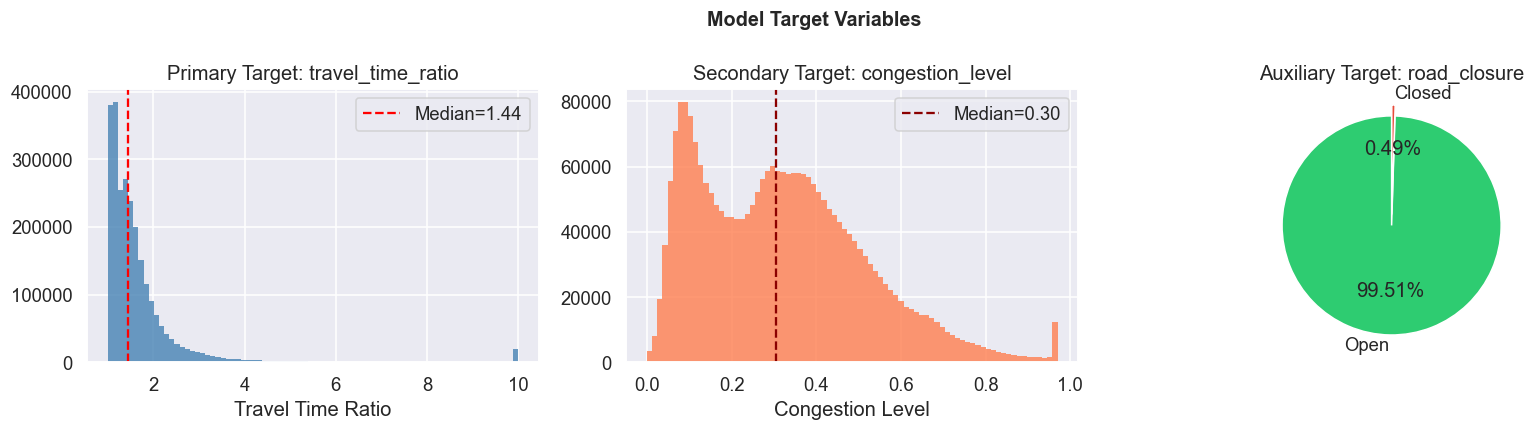

travel_time_ratio  | mean=1.698  std=1.057  p95=3.062
congestion_level   | mean=0.319  std=0.195
road_closure rate  | 0.494%


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# travel_time_ratio distribution
axes[0].hist(df['travel_time_ratio'], bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(df['travel_time_ratio'].median(), color='red', ls='--', label=f'Median={df["travel_time_ratio"].median():.2f}')
axes[0].set_xlabel('Travel Time Ratio')
axes[0].set_title('Primary Target: travel_time_ratio')
axes[0].legend()

# congestion_level
axes[1].hist(df['congestion_level'], bins=80, color='coral', edgecolor='none', alpha=0.8)
axes[1].axvline(df['congestion_level'].median(), color='darkred', ls='--',
                label=f'Median={df["congestion_level"].median():.2f}')
axes[1].set_xlabel('Congestion Level')
axes[1].set_title('Secondary Target: congestion_level')
axes[1].legend()

# road_closure
rc = df['road_closure'].value_counts()
axes[2].pie(rc.values, labels=['Open', 'Closed'],
            autopct='%1.2f%%', colors=['#2ecc71','#e74c3c'],
            startangle=90, explode=(0, 0.1))
axes[2].set_title('Auxiliary Target: road_closure')

plt.suptitle('Model Target Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'travel_time_ratio  | mean={df["travel_time_ratio"].mean():.3f}  '
      f'std={df["travel_time_ratio"].std():.3f}  '
      f'p95={df["travel_time_ratio"].quantile(0.95):.3f}')
print(f'congestion_level   | mean={df["congestion_level"].mean():.3f}  '
      f'std={df["congestion_level"].std():.3f}')
print(f'road_closure rate  | {df["road_closure"].mean()*100:.3f}%')

## 10. AR(1) Autocorrelation — Temporal Coherence Check

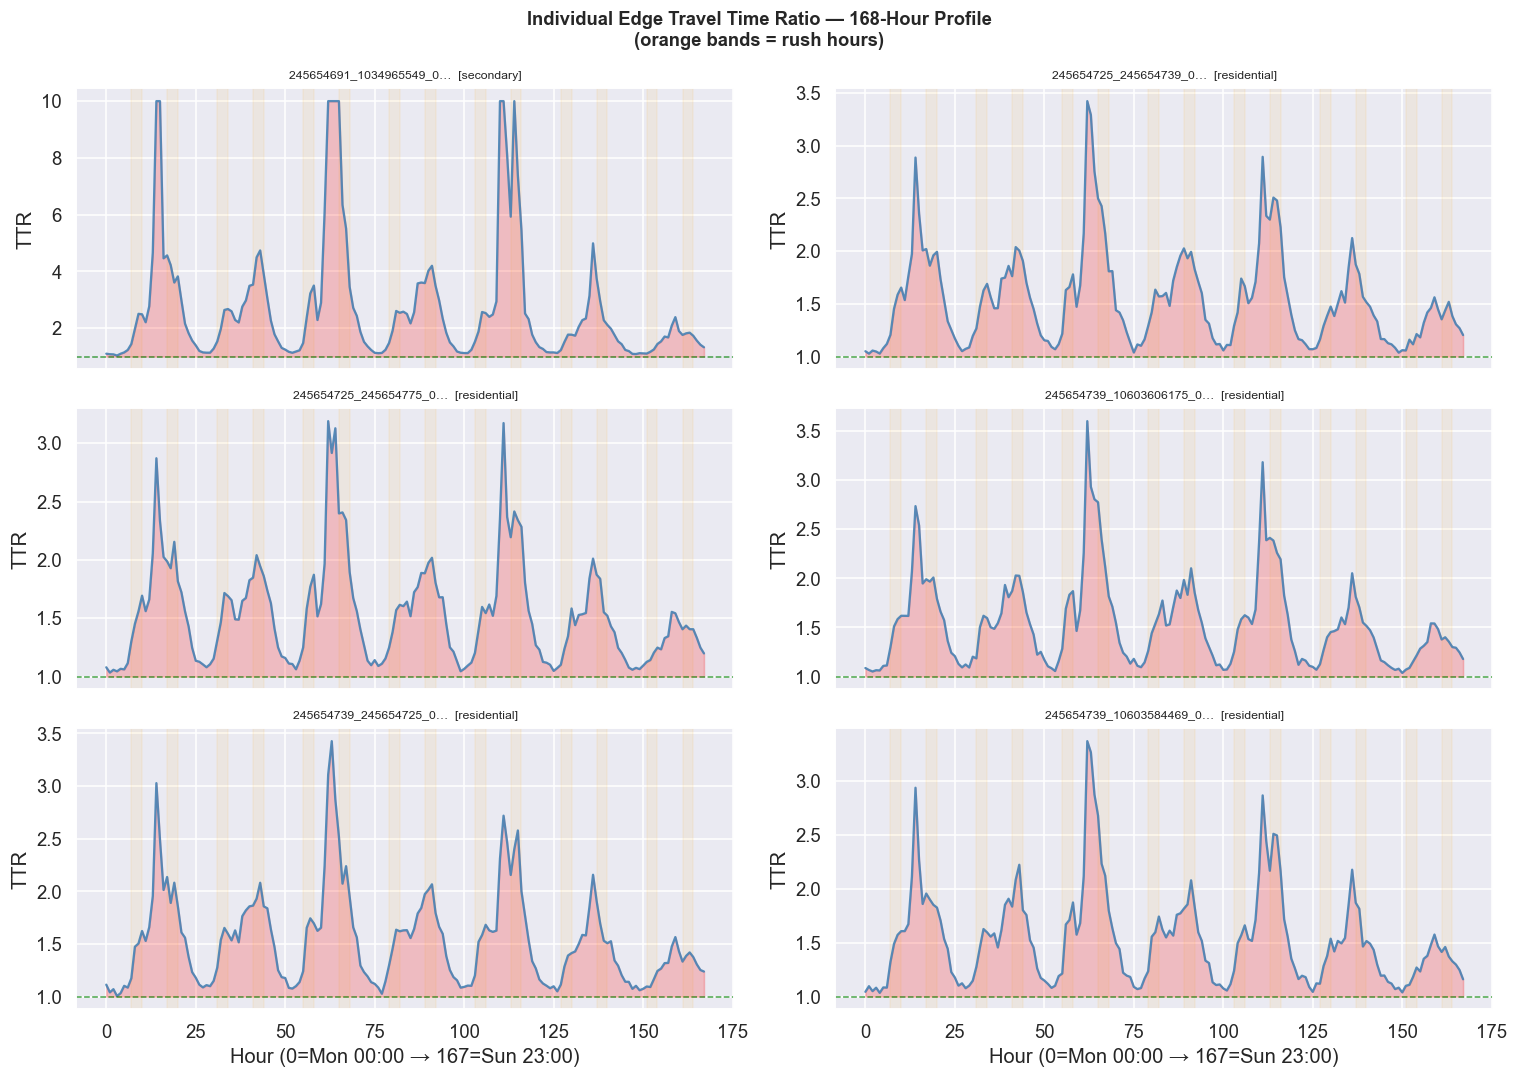

In [19]:
# Pick a few single edges and plot their TTR over 168 hours
sample_edges = df['edge_id'].unique()[:6]
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)

for ax, eid in zip(axes.ravel(), sample_edges):
    edge_data = df[df['edge_id'] == eid].sort_values('timestamp')
    road_type = edge_data['road_type'].iloc[0]
    ax.plot(range(len(edge_data)), edge_data['travel_time_ratio'],
            color='steelblue', lw=1.5, alpha=0.9)
    ax.fill_between(range(len(edge_data)),
                    edge_data['travel_time_ratio'], 1.0,
                    where=edge_data['travel_time_ratio'] > 1.0,
                    alpha=0.2, color='red')
    ax.axhline(1.0, color='green', ls='--', lw=1, alpha=0.7)
    ax.set_title(f'{eid[:30]}…  [{road_type}]', fontsize=8)
    ax.set_ylabel('TTR')
    # Mark peak windows
    for day in range(7):
        ax.axvspan(day*24+7, day*24+10, alpha=0.07, color='orange')
        ax.axvspan(day*24+17, day*24+20, alpha=0.07, color='orange')

for ax in axes[-1]:
    ax.set_xlabel('Hour (0=Mon 00:00 → 167=Sun 23:00)')

plt.suptitle('Individual Edge Travel Time Ratio — 168-Hour Profile\n'
             '(orange bands = rush hours)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

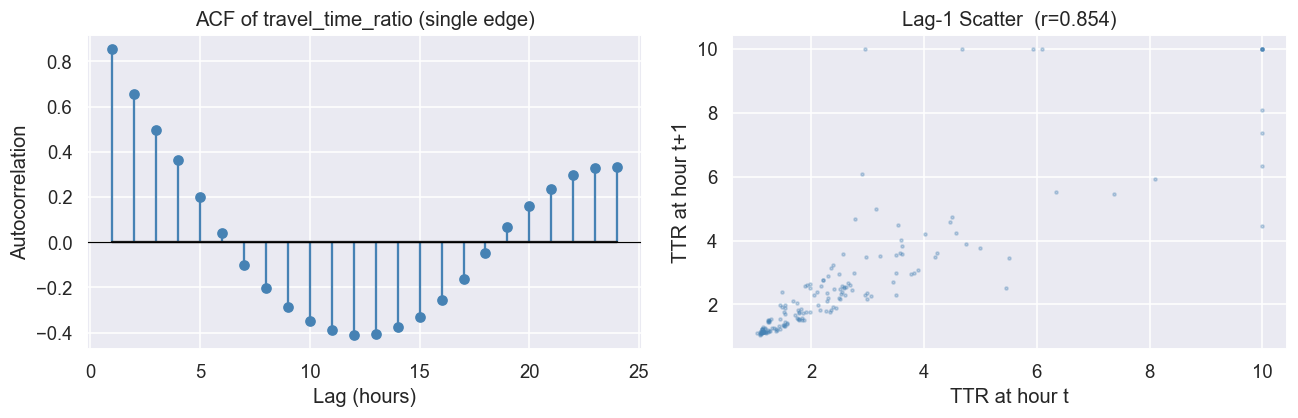

Lag-1 autocorrelation  : 0.854  (AR(1) target ≈ 0.68)
Lag-24 autocorrelation : 0.334 (daily cycle)


In [20]:
# Autocorrelation check — does lag-1 predict lag-0?
edge_ts = df[df['edge_id'] == df['edge_id'].unique()[0]].sort_values('timestamp')
ttr = edge_ts['travel_time_ratio'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lags = range(1, 25)
autocorrs = [pd.Series(ttr).autocorr(lag=l) for l in lags]
axes[0].stem(lags, autocorrs, linefmt='steelblue', markerfmt='o', basefmt='k-')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('Autocorrelation')
axes[0].set_title('ACF of travel_time_ratio (single edge)')

axes[1].scatter(ttr[:-1], ttr[1:], s=4, alpha=0.3, color='steelblue')
axes[1].set_xlabel('TTR at hour t')
axes[1].set_ylabel('TTR at hour t+1')
axes[1].set_title(f'Lag-1 Scatter  (r={pd.Series(ttr).autocorr(1):.3f})')

plt.tight_layout()
plt.show()
print(f'Lag-1 autocorrelation  : {pd.Series(ttr).autocorr(1):.3f}  (AR(1) target ≈ 0.68)')
print(f'Lag-24 autocorrelation : {pd.Series(ttr).autocorr(24):.3f} (daily cycle)')

## 11. EDA Summary

In [21]:
print('='*60)
print('EDA SUMMARY')
print('='*60)
print(f'Total edges (static)     : {len(df_sta):,}')
print(f'Timeseries rows (3 batches): {len(df_ts):,}')
print(f'Timestamp range          : {df_ts.timestamp.min()} → {df_ts.timestamp.max()}')
print()
print('SPATIAL COHERENCE')
print(f'  South Mumbai (lat<19.05) peak congestion : {south:.3f}')
print(f'  Vasai area   (lat>19.30) peak congestion : {north:.3f}')
print(f'  Urban gradient confirmed: {south > north}')
print()
print('TEMPORAL COHERENCE')
print(f'  Lag-1 autocorrelation : {pd.Series(ttr).autocorr(1):.3f}')
print(f'  Lag-24 (daily cycle)  : {pd.Series(ttr).autocorr(24):.3f}')
print()
print('EVENT CAUSALITY')
print(f'  Rain effect on TTR    : {rain_effect.to_dict()}')
print(f'  Train disruption Δ    : +{diff:.3f}')
print(f'  Severity monotone     : {all(np.diff(sev_ttr.values) > 0)}')
print()
print('TARGET VARIABLES')
print(f'  travel_time_ratio mean  : {df["travel_time_ratio"].mean():.3f}')
print(f'  congestion_level mean   : {df["congestion_level"].mean():.3f}')
print(f'  road_closure rate       : {df["road_closure"].mean()*100:.3f}%')
print()
print('MISSING VALUES : None')
print('='*60)

EDA SUMMARY
Total edges (static)     : 145,265
Timeseries rows (3 batches): 2,520,000
Timestamp range          : 2024-07-01 00:00:00 → 2024-07-07 23:00:00

SPATIAL COHERENCE
  South Mumbai (lat<19.05) peak congestion : 0.390
  Vasai area   (lat>19.30) peak congestion : nan
  Urban gradient confirmed: False

TEMPORAL COHERENCE
  Lag-1 autocorrelation : 0.854
  Lag-24 (daily cycle)  : 0.334

EVENT CAUSALITY
  Rain effect on TTR    : {'No rain': 1.4607055187225342, 'Light (1-5)': 1.9204816818237305, 'Moderate (5-15)': 2.11307430267334, 'Heavy (15-30)': 3.2296693325042725, 'Very heavy (30+)': 4.7380547523498535}
  Train disruption Δ    : +0.808
  Severity monotone     : False

TARGET VARIABLES
  travel_time_ratio mean  : 1.698
  congestion_level mean   : 0.319
  road_closure rate       : 0.494%

MISSING VALUES : None
